# Visual Map Validation for PALM Experiments
Plot and analyse maps generated by the ``palm_experiments.py`` script to ensure they are plausible / generated correctly. 

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

Folders and Paths

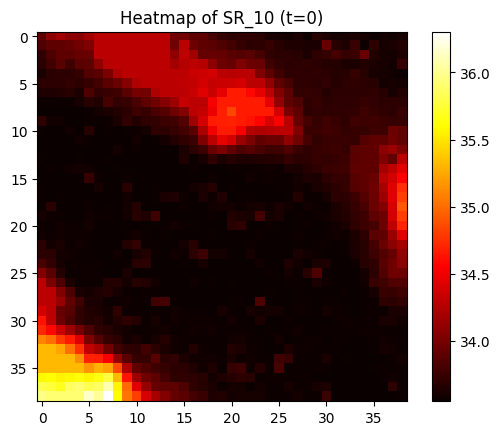

In [6]:
datafolder = 'C:/Users/ushe/Documents/LinuxDownload/palm_experiments/mb4/SR_10'
filename = 'LR_0.8.npy'
temp_array = np.load(os.path.join(datafolder, filename))

# Get the basename of the datafolder path
basename = os.path.basename(datafolder)

# Create the heatmap
time = 0
plt.imshow(temp_array[time, :, :, 0], cmap='hot')
plt.title(f"Heatmap of {basename} (t={time})")
plt.colorbar()
plt.show()

In [13]:
all_nans = np.all(np.isnan(temp_array))
print('Temperature array is all nans' if all_nans else 'Teperature array contains valid data') 

Temperature array is all nans


Test all sparse arrays from all PALM files

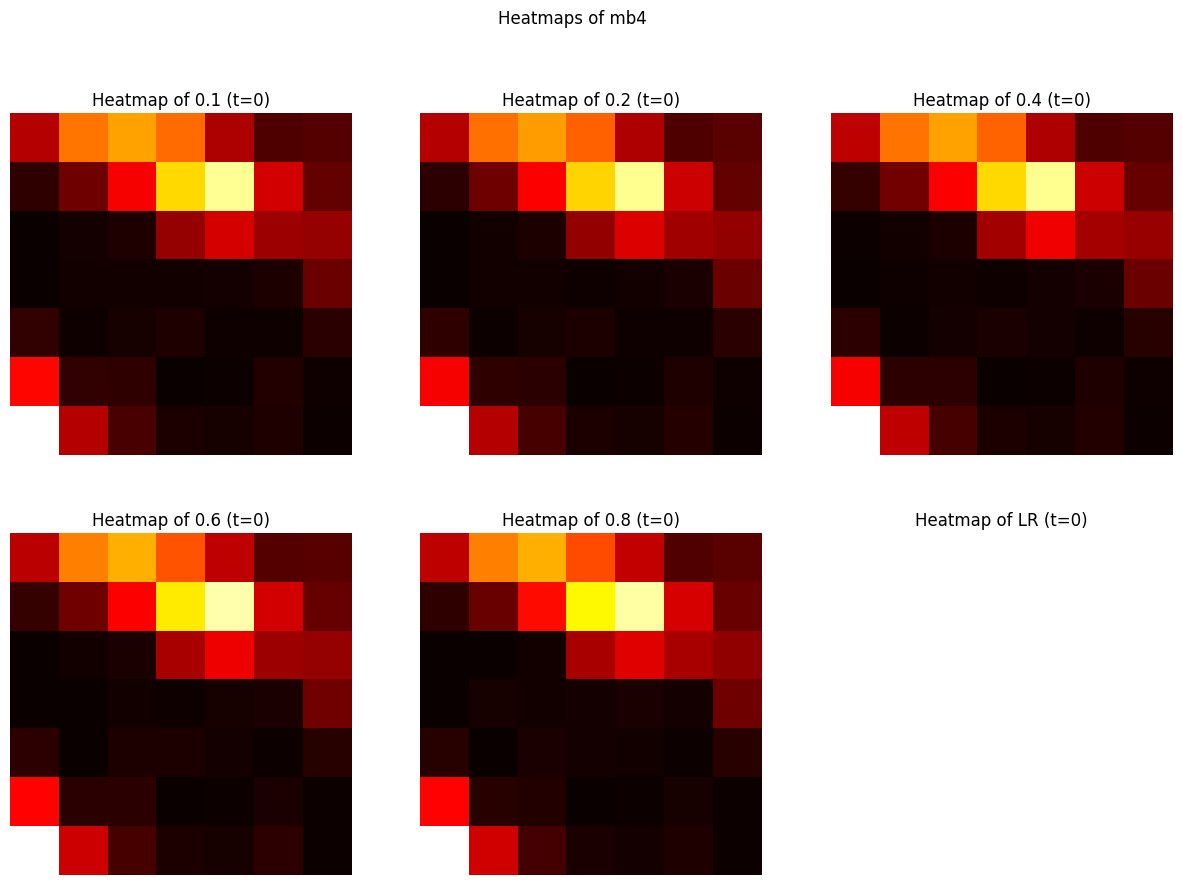

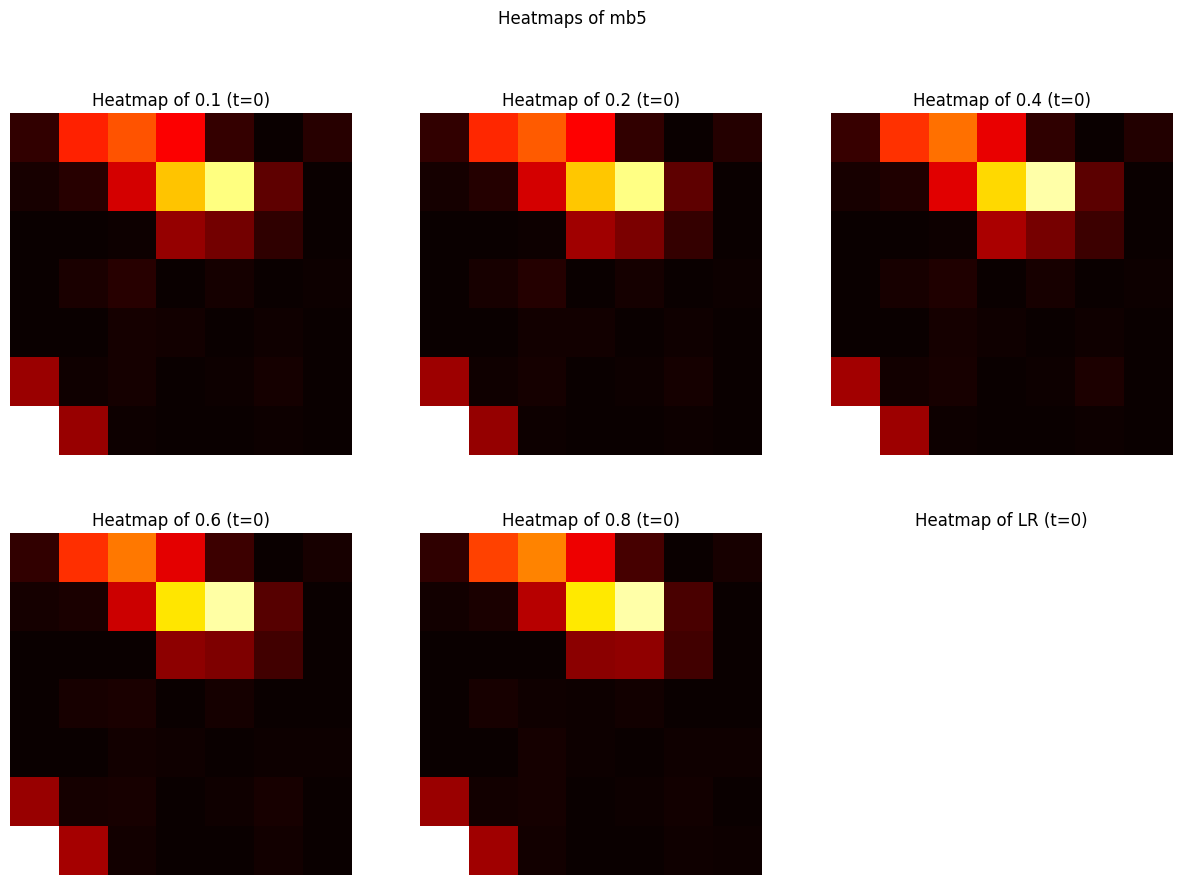

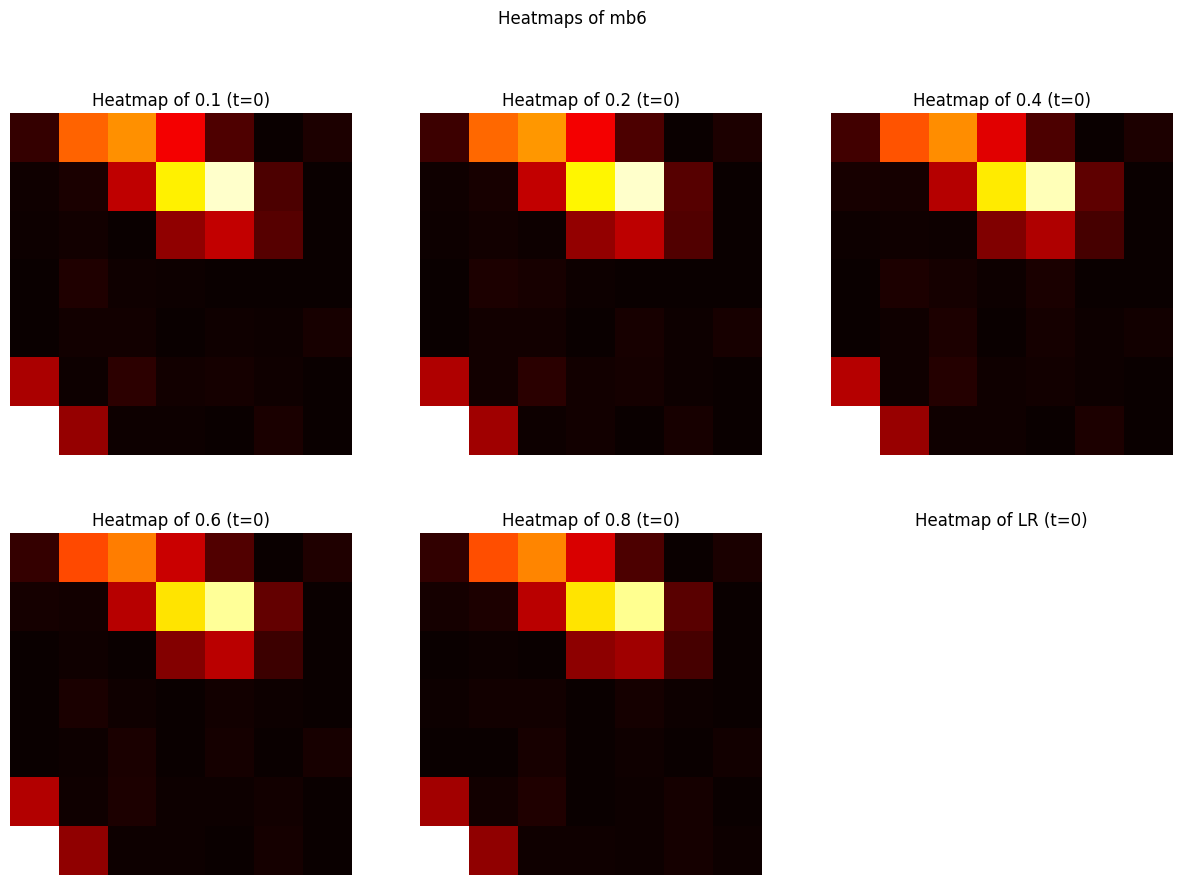

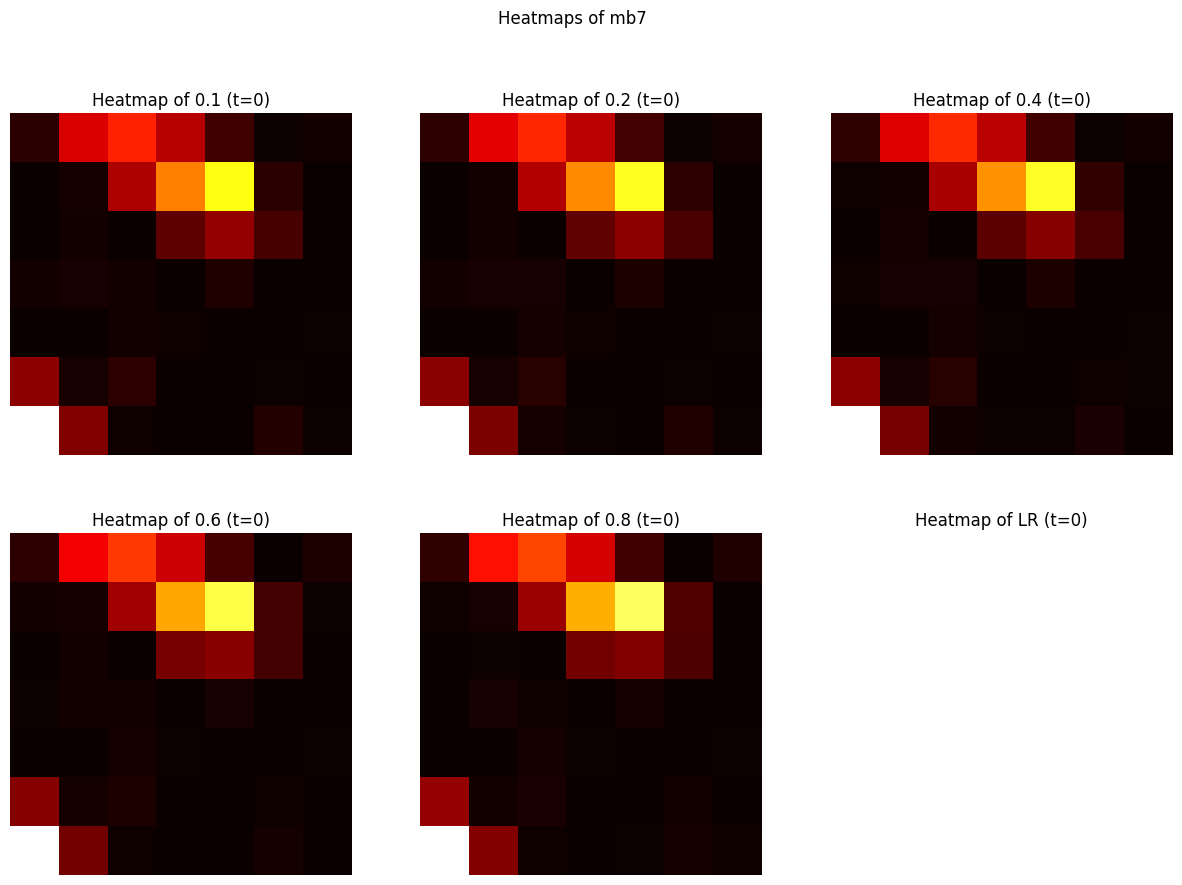

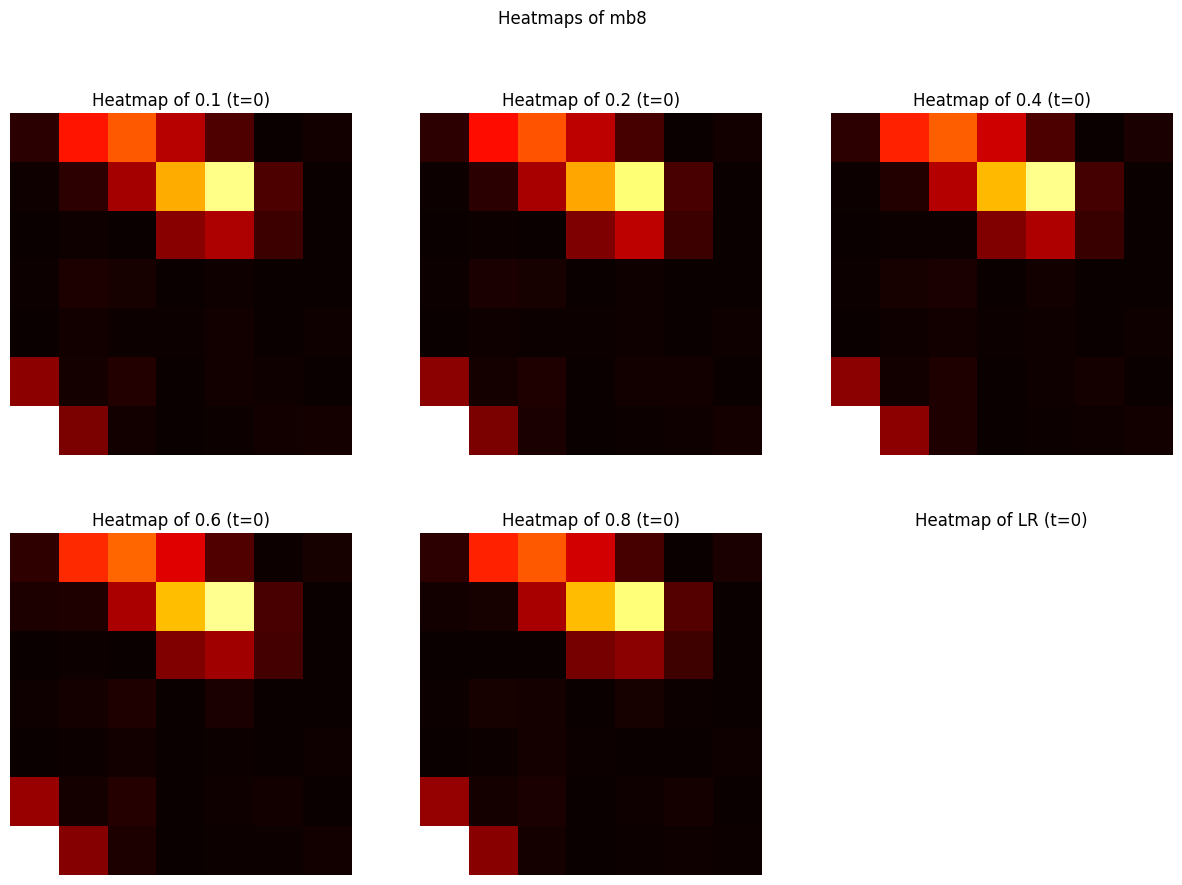

In [14]:
datafolder = 'C:/Users/ushe/Documents/LinuxDownload/palm_experiments/'
PALMfiles = ['mb4', 'mb5', 'mb6', 'mb7', 'mb8']
filenames = ['LR_0.1.npy', 'LR_0.2.npy', 'LR_0.4.npy', 'LR_0.6.npy','LR_0.8.npy', 'insitu_LR.npy']
plotname = [f'{filename.split("_")[1].split(".npy")[0]}' for filename in filenames]

for palmfile in PALMfiles:
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Heatmaps of {palmfile}')
    for i, ax in enumerate(axs.flat):
        temp_array = np.load(os.path.join(datafolder, palmfile, filenames[i]))
        ax.imshow(temp_array[0, :, :, 0], cmap='hot')
        ax.set_title(f"Heatmap of {plotname[i]} (t=0)")
        ax.axis('off')


In [20]:
pretrainfile = 'C:/Users/ushe/Documents/LinuxDownload/palm_experiments/test1/pretrain.npy'
pretrainfile = np.load(pretrainfile)
trainfile = 'C:/Users/ushe/Documents/LinuxDownload/palm_experiments/test1/train.npy'
trainfile = np.load(trainfile)

In [21]:
print(f'pretrainfile shape: {pretrainfile.shape}')
print(f'trainfile shape: {trainfile.shape}')

pretrainfile shape: (4471, 392, 392)
trainfile shape: (263, 392, 392)


In [22]:
print(f'min value in pretrainfile: {np.min(pretrainfile)}')
print(f'max value in pretrainfile: {np.max(pretrainfile)}')
print(f'min value in trainfile: {np.min(trainfile)}')
print(f'max value in trainfile: {np.max(trainfile)}')

min value in pretrainfile: -9999.0
max value in pretrainfile: 45.314544677734375
min value in trainfile: 10.555780029296898
max value in trainfile: 45.31453857421877


In [23]:
print('nan values in pretrainfile: ', np.isnan(pretrainfile).sum())
print('nan values in trainfile: ', np.isnan(trainfile).sum())

nan values in pretrainfile:  0
nan values in trainfile:  0


In [26]:
type(trainfile[0, 0, 0])

numpy.float64

# Visualisation of GAN Output

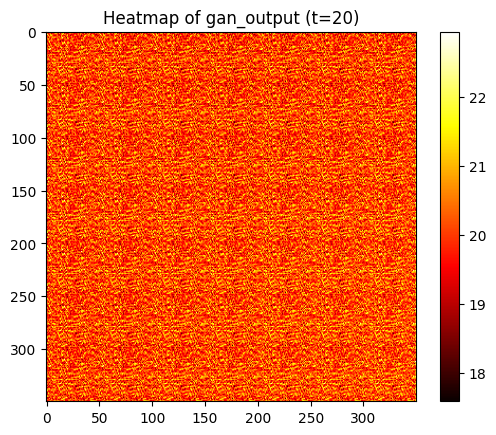

In [15]:
datafolder = 'C:/Users/ushe/Documents/LinuxDownload/palm_experiments/gan_output'
filename = 'temperature-20240718-172858/dataSR.npy'
temp_array = np.load(os.path.join(datafolder, filename))

# Get the basename of the datafolder path
basename = os.path.basename(datafolder)

# Create the heatmap
time = 20
plt.imshow(temp_array[time, :, :, 0], cmap='hot')
plt.title(f"Heatmap of {basename} (t={time})")
plt.colorbar()
plt.show()

# Aggregated Dataset

In [18]:
file = 'C:/Users/ushe/Documents/LinuxDownload/palm_experiments/test1/pretrain.npy'
pretrain = np.load(file)

In [19]:
print(pretrain.shape)
print(np.sum(np.isnan(pretrain))) 

(4471, 392, 392)
0


In [21]:
def adjust_dimensions(array, sf):
    """
    Adjusts an array to be scalable to the given scaling factor, meaning that all dimenions are divisible by the
    scaling factor.
    """
    return array[:, 0:array.shape[1] - array.shape[1] % sf,  0:array.shape[2] - array.shape[2] % sf, :]


def lower_resolution(hr_map, sr_factor):
    """
    Lowers the resolution of sparse arrays using a simple nanmean to avoid full nan arrays when using the 
    standard conv2D downscaling method. 
    """
    lr_map = np.zeros((hr_map.shape[0], hr_map.shape[1] // sr_factor, hr_map.shape[2] // sr_factor, hr_map.shape[3]))
    for i in range(lr_map.shape[1]):
        for j in range(lr_map.shape[2]):
            for t in range(lr_map.shape[0]):
                lr_map[t, i, j, :] = np.nanmean(hr_map[t, i*sr_factor : (i+1)*sr_factor, 
                                                       j*sr_factor : (j+1)*sr_factor, :])
    return lr_map


def generate_LRHR_from_array(arrayHR, scalingfactor):
    if len(arrayHR.shape) == 3:
        arrayHR = arrayHR.reshape(arrayHR.shape[0], arrayHR.shape[1], arrayHR.shape[2], 1)
    imagearray_HR = adjust_dimensions(arrayHR, scalingfactor)
    imagearray_LR = lower_resolution(imagearray_HR, scalingfactor)
    # imagearray_LR = utils.downscale_image(imagearray_HR, scalingfactor)
    return imagearray_HR, imagearray_LR

In [22]:
hr, lr = generate_LRHR_from_array(pretrain, 10)

In [29]:
import tensorflow as tf

def _bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def generate_TFRecords(filename, data_HR=None, data_LR=None, mode='test'):
    '''
        Generate TFRecords files for model training or testing

        inputs:
            filename - filename for TFRecord (should by type *.tfrecord)
            data     - numpy array of size (N, h, w, c) containing data to be written to TFRecord
            model    - if 'train', then data contains HR data that is coarsened k times 
                       and both HR and LR data written to TFRecord
                       if 'test', then data contains LR data 
            K        - downscaling factor, must be specified in training mode

        outputs:
            No output, but .tfrecord file written to filename
    '''
    if mode == 'train':
        assert data_HR is not None, 'In training mode, high resolution data must be given'
        assert data_LR is not None, 'In training mode, low resolution data must be given'
        shape = data_HR.shape[0]
    if mode == 'test':
        assert data_LR is not None, 'In testing mode, low-resolution data must be given'
        shape = data_LR.shape[0]

    with tf.compat.v1.python_io.TFRecordWriter(filename) as writer:
        for j in range(shape):
            if mode == 'train':
                h_HR, w_HR, c = data_HR[j, ...].shape
                h_LR, w_LR, c = data_LR[j, ...].shape
                features = tf.train.Features(feature={
                                     'index': _int64_feature(j),
                                   'data_LR': _bytes_feature(data_LR[j, ...].tostring()),
                                      'h_LR': _int64_feature(h_LR),
                                      'w_LR': _int64_feature(w_LR),
                                   'data_HR': _bytes_feature(data_HR[j, ...].tostring()),
                                      'h_HR': _int64_feature(h_HR),
                                      'w_HR': _int64_feature(w_HR),
                                         'c': _int64_feature(c)})
            elif mode == 'test':
                h_LR, w_LR, c = data_LR[j, ...].shape
                features = tf.train.Features(feature={
                                     'index': _int64_feature(j),
                                   'data_LR': _bytes_feature(data_LR[j, ...].tostring()),
                                      'h_LR': _int64_feature(h_LR),
                                      'w_LR': _int64_feature(w_LR),
                                         'c': _int64_feature(c)})

            example = tf.train.Example(features=features)
            writer.write(example.SerializeToString())


tfrecordpath = 'C:/Users/ushe/Documents/LinuxDownload/palm_experiments/test1/pretrain_10.tfrecord'
generate_TFRecords(tfrecordpath, data_HR=hr, data_LR=lr, mode='train')

C:\Users\ushe\AppData\Local\Temp\ipykernel_27508\4031965048.py:39: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  'data_LR': _bytes_feature(data_LR[j, ...].tostring()),
C:\Users\ushe\AppData\Local\Temp\ipykernel_27508\4031965048.py:42: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  'data_HR': _bytes_feature(data_HR[j, ...].tostring()),


KeyboardInterrupt: 

In [7]:
import tensorflow as tf
import numpy as np

In [35]:
def _parse_train_(serialized_example, mu_sig=None):
    '''
        Parser data from TFRecords for the models to read in for (pre)training

        inputs:
            serialized_example - batch of data drawn from tfrecord
            mu_sig             - mean, standard deviation if known

        outputs:
            idx     - array of indicies for each sample
            data_LR - array of LR images in the batch
            data_HR - array of HR images in the batch
    '''

    feature = {'index': tf.compat.v1.FixedLenFeature([], tf.int64),
                'data_LR': tf.compat.v1.FixedLenFeature([], tf.string),
                'h_LR': tf.compat.v1.FixedLenFeature([], tf.int64),
                'w_LR': tf.compat.v1.FixedLenFeature([], tf.int64),
                'data_HR': tf.io.FixedLenFeature([], tf.string),
                'h_HR': tf.compat.v1.FixedLenFeature([], tf.int64),
                'w_HR': tf.compat.v1.FixedLenFeature([], tf.int64),
                'c': tf.compat.v1.FixedLenFeature([], tf.int64)}
    example = tf.compat.v1.parse_single_example(serialized_example, feature)

    idx = example['index']

    h_LR, w_LR = example['h_LR'], example['w_LR']
    h_HR, w_HR = example['h_HR'], example['w_HR']

    c = example['c']

    data_LR = tf.compat.v1.decode_raw(example['data_LR'], tf.float64)
    data_HR = tf.compat.v1.decode_raw(example['data_HR'], tf.float64)

    data_LR = tf.reshape(data_LR, (h_LR, w_LR, c))
    data_HR = tf.reshape(data_HR, (h_HR, w_HR, c))

    if mu_sig is not None:
        data_LR = (data_LR - mu_sig[0]) / mu_sig[1]
        data_HR = (data_HR - mu_sig[0]) / mu_sig[1]

    return idx, data_LR, data_HR

In [8]:
# tfrecordpath = 'C:/Users/ushe/Documents/LinuxDownload/palm_experiments/mb4/SR_10/baseline_train.tfrecord'
tfrecordpath = 'C:/Users/ushe/Documents/LinuxDownload/palm_experiments/test1/pretrain_10.tfrecord'
tf.compat.v1.disable_eager_execution()
batch_size = 100
dataset = tf.compat.v1.data.TFRecordDataset(tfrecordpath)
dataset = dataset.map(_parse_train_).batch(batch_size)

iterator = tf.compat.v1.data.make_one_shot_iterator(dataset)
_, _, HR_out = iterator.get_next()

with tf.compat.v1.Session() as sess:
    N, mu, sigma = 0, 0, 0
    try:
        while True:
            print(HR_out.shape)
            data_HR = sess.run(HR_out)
            print(data_HR.shape)

            N_batch, h, w, c = data_HR.shape
            N_new = N + N_batch

            mu_batch = np.mean(data_HR, axis=(0, 1, 2))
            sigma_batch = np.var(data_HR, axis=(0, 1, 2))

            sigma = (N / N_new) * sigma + (N_batch / N_new) * sigma_batch + (N * N_batch / N_new ** 2) * (
                        mu - mu_batch) ** 2
            mu = (N / N_new) * mu + (N_batch / N_new) * mu_batch

            N = N_new

    except tf.errors.OutOfRangeError:
        pass

mu_sig = [mu, np.sqrt(sigma)]

(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 390, 390, 1)
(None, None, None, None)
(100, 3

In [36]:
tfrecordpath = 'C:/Users/ushe/Documents/LinuxDownload/palm_experiments/test1/train_10.tfrecord'
tf.compat.v1.disable_eager_execution()
batch_size = 100
dataset = tf.compat.v1.data.TFRecordDataset(tfrecordpath)
dataset = dataset.map(_parse_train_).batch(batch_size)

iterator = tf.compat.v1.data.make_one_shot_iterator(dataset)
_, _, HR_out = iterator.get_next()

data_HR = None

with tf.compat.v1.Session() as sess:
    print(HR_out)
    data_HR = sess.run(HR_out)

Tensor("IteratorGetNext_7:2", shape=(None, None, None, None), dtype=float64)


InvalidArgumentError: Graph execution error:

Feature: data_HR (data type: string) is required but could not be found.
	 [[{{node ParseSingleExample/ParseExample/ParseExampleV2}}]]
	 [[IteratorGetNext_7]]

In [31]:
train_array = np.load('C:/Users/ushe/Documents/LinuxDownload/palm_experiments/test1/train_HR.npy')

In [33]:
print(train_array.shape)
print(f'train min: {np.min(train_array)}, train max: {np.max(train_array)}')

(263, 390, 390, 1)
train min: 10.555780029296898, train max: 45.31453857421877


In [28]:
np.sum(np.isnan(pretrain))

0